In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
from pathlib import Path

import dask
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from dask.diagnostics import ProgressBar
import calendar

sys.path.append("../..")
from src.data_processing import DataProcessingDask
from matplotlib.patches import Patch

sns.set_style("whitegrid", {"grid.color": ".93"})
os.environ["USE_PYGEOS"] = "0"

In [3]:
# use seaborn colorblind palette
sns.set_palette("colorblind")

# Load

In [4]:
paths = json.load(open("../../paths_projections.json"))

path_data = Path(paths["path_data_ror"])

path_data_hydro = path_data / "hydropower"
path_data_polygons = path_data / "polygons"
path_swiss_maps = path_data / "maps" / "swissboundaries3d_2023-01_2056_5728/"

path_figs = Path(paths["path_figs"])

In [5]:
dask.config.set(num_workers=15, threads_per_worker=16)
dask.config.set(
    {
        "distributed.worker.memory.target": 0.7,  # Spill to disk at 70%
        "distributed.worker.memory.spill": 0.8,  # Start spilling at 80%
        "distributed.worker.memory.pause": 0.9,  # Pause worker at 90%
        "array.chunk-size": "512MiB",
        "logging.distributed": "error",  # Less verbose logs
    }
)

In [6]:
# climate_model_chain = None
# climate_scenario = None

climate_model_chain = "CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1"
climate_scenario = "rcp26"

In [7]:
prevah_grid_resolution = 500  # in meters

In [8]:
processing = DataProcessingDask(
    "../../paths_projections.json", climate_model_chain, climate_scenario
)

Loading data


In [9]:
if climate_model_chain is None and climate_scenario is None:
    df_prevah_pts_in_polygons_filename = "df_prevah_obs_pts_in_polygons.csv"
else:
    df_prevah_pts_in_polygons_filename = "df_prevah_proj_pts_in_polygons.csv"

if processing.weighted:
    df_prevah_pts_in_polygons_filename = (
        df_prevah_pts_in_polygons_filename.removesuffix(".csv") + "_weighted.csv"
    )

In [10]:
climate_scenarios = ["rcp26", "rcp45", "rcp85"]
ds_gen_dict = {
    scenario: xr.open_zarr(
        processing.path_data_hydro
        / "hydropower_generation"
        / f"ds_prevah_{processing.climate_model_chain}_{scenario}_hydropower_production_ror.zarr",
        chunks="auto",
    )
    for scenario in climate_scenarios
}
ds_gen_dict["obs"] = xr.open_zarr(
    processing.path_data_hydro
    / "hydropower_generation"
    / "ds_prevah_obs_hydropower_production_ror.zarr",
    chunks="auto",
)
ds_gen_obs = ds_gen_dict["obs"]
ds_gen_rcp26 = ds_gen_dict["rcp26"]
ds_gen_rcp45 = ds_gen_dict["rcp45"]
ds_gen_rcp85 = ds_gen_dict["rcp85"]

In [11]:
bias_correction_factors = {}
for scenario in climate_scenarios:
    bias_correction_factors[scenario] = xr.open_zarr(
        processing.path_data_hydro
        / "hydropower_generation"
        / f"ds_prevah_{processing.climate_model_chain}_{scenario}_hydropower_production_ror_monthly_bias_correction_factors.zarr",
    )
bias_correction_factors["obs"] = xr.open_zarr(
    processing.path_data_hydro
    / "hydropower_generation"
    / "ds_prevah_obs_hydropower_production_ror_monthly_bias_correction_factors.zarr",
)

In [12]:
df_reported_generation = pd.read_csv(
    processing.path_data_ror
    / "energy"
    / "ogd35_schweizerische_elektrizitaetsbilanz_monatswerte.csv"
)
df_reported_generation_ror = df_reported_generation[df_reported_generation.Jahr < 2023][
    ["Jahr", "Monat", "Erzeugung_laufwerk_GWh"]
].rename({"Erzeugung_laufwerk_GWh": "Reported Generation"}, axis=1)
df_reported_generation_ror["Reported Generation"] *= 1e-3  # to TWh

# Analysis

In [13]:
periods = {"1991-2020": (1991, 2020), "2021-2050": (2021, 2050)}

In [14]:
def compute_yearly_sum_from_dataset(ds, value_name="gen_yearly"):
    """Compute yearly totals from a hydropower xarray.Dataset `ds` with data var `gen`.
    Returns (yearly_da, df) where:
      - yearly_da: xarray.DataArray of yearly totals (time dimension)
      - df: pandas.DataFrame with columns ['time', value_name, 'year']
    """
    yearly_gen = ds.gen.resample(time="YE").sum(dim="time").sum(dim="hydropower")
    yearly_da = yearly_gen
    df = yearly_da.to_dataframe(name=value_name).reset_index()
    df["year"] = df["time"].dt.year
    return yearly_da, df

In [15]:
def compute_monthly_sum_from_dataset(ds, value_name="gen_monthly"):
    """
    Compute monthly totals from a hydropower xarray.Dataset `ds` with data var `gen`.
    Returns (monthly_da, df) where:
      - monthly_da: xarray.DataArray of monthly totals (time dimension)
      - df: pandas.DataFrame with columns ['time', value_name, 'year', 'month']
    """
    # sum per calendar month and across all hydropower plants
    monthly_gen = ds.gen.resample(time="ME").sum(dim="time").sum(dim="hydropower")
    monthly_da = monthly_gen

    df = monthly_da.to_dataframe(name=value_name).reset_index()
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month
    df = df[["time", "year", "month", value_name]]

    return monthly_da, df

In [16]:
def compute_monthly_generation_from_ds(
    ds_gen, gdf_hydropower_locations, start_year=None, end_year=None, resample_rule="ME"
):
    """
    For each year in ds_gen, sum monthly generation over hydropower plants that were
    already in operation that year according to gdf_hydropower_locations.
    Returns an xarray.Dataset concatenated over time with generation aggregated.
    """
    list_ds = []
    hp_all = ds_gen.hydropower.to_numpy()
    years = np.unique(ds_gen.time.dt.year.values)
    if start_year is not None:
        years = years[years >= int(start_year)]
    if end_year is not None:
        years = years[years <= int(end_year)]

    for y in years:
        wasta = gdf_hydropower_locations[
            (gdf_hydropower_locations["BeginningOfOperation"] <= int(y))
            & (gdf_hydropower_locations["WASTANumber"].isin(hp_all))
        ]["WASTANumber"].tolist()
        if not wasta:
            # skip years with no plants in operation (keeps function simple)
            continue
        ds_year = ds_gen.sel(hydropower=wasta, time=str(int(y)))
        ds_monthly = ds_year.resample(time=resample_rule).sum(
            dim=["hydropower", "time"]
        )
        list_ds.append(ds_monthly)

    if not list_ds:
        raise ValueError(
            "No monthly generation data produced (no matching plants/years)."
        )

    return xr.concat(list_ds, dim="time").compute()

In [17]:
from scipy.stats.mstats import theilslopes
from sklearn.linear_model import TheilSenRegressor


def compute_theilsen_trends(df, col, periods=periods, alpha=0.95):
    """Compute Theil-Sen trends for `col` in `df` for the requested periods.
    Returns a pandas DataFrame indexed by period (same columns as previous df_trends).
    """
    rows = []
    for name, (y0, y1) in periods.items():
        dfp = df[(df.year >= y0) & (df.year <= y1)].copy()
        if dfp.empty:
            raise ValueError(f"No data for period {name} and column {col}")

        X = dfp["year"].to_numpy().reshape(-1, 1)
        y = dfp[col].to_numpy()

        try:
            slope, intercept, lo_slope, hi_slope = theilslopes(
                y, dfp["year"].to_numpy(), alpha=alpha
            )
            method = f"scipy.theilslopes ({int(alpha*100)}% CI)"
        except Exception:
            model = TheilSenRegressor(random_state=0)
            model.fit(X, y)
            slope = float(model.coef_[0])
            intercept = float(model.intercept_)
            lo_slope, hi_slope = (np.nan, np.nan)
            method = "sklearn.TheilSenRegressor (no CI)"

        slope_per_year = float(slope)
        slope_per_decade = slope_per_year * 10.0
        mean_val = y.mean()
        rel_per_decade_pct = 100.0 * (slope_per_decade / mean_val)

        rows.append(
            {
                "period": name,
                "n_years": len(dfp),
                "slope_TWh_per_year": slope_per_year,
                "slope_TWh_per_decade": slope_per_decade,
                "slope_CI_lower": lo_slope,
                "slope_CI_upper": hi_slope,
                "mean_TWh": mean_val,
                "rel_change_pct_per_decade": rel_per_decade_pct,
                "method": method,
            }
        )

    return pd.DataFrame(rows).set_index("period")

## Pre-bias correction comparison

In [19]:
yearly_da_rcp26, df26 = compute_yearly_sum_from_dataset(
    ds_gen_rcp26, "gen_yearly"
)
yearly_da_rcp45, df45 = compute_yearly_sum_from_dataset(
    ds_gen_rcp45, "gen_yearly"
)
yearly_da_rcp85, df85 = compute_yearly_sum_from_dataset(
    ds_gen_rcp85, "gen_yearly"
)

# combine into one dataframe (aligned by year)
df_combined = pd.merge(
    df26[["year", "gen_yearly"]],
    df45[["year", "gen_yearly"]],
    on="year",
    suffixes=("_rcp26", "_rcp45"),
)
df_combined = pd.merge(
    df_combined,
    df85[["year", "gen_yearly"]].rename({"gen_yearly": "gen_yearly_rcp85"}, axis=1),
    on="year",
)

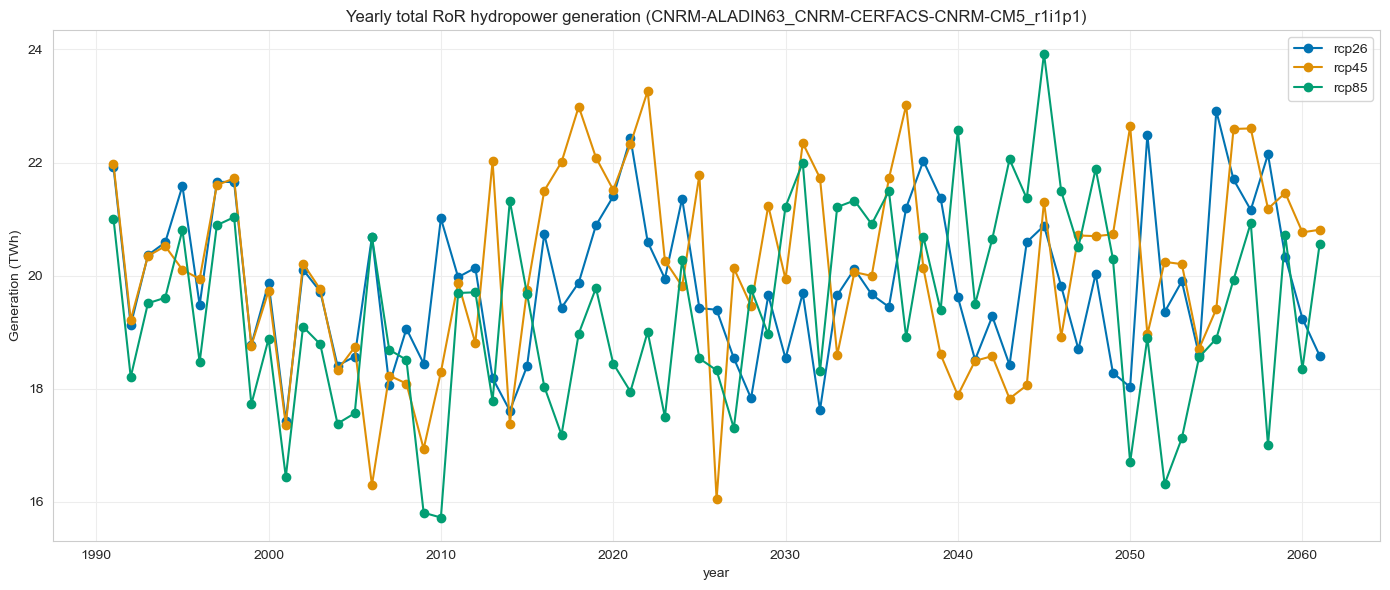

In [20]:
# plot both series
ax = df_combined.set_index("year").plot(figsize=(14, 6), marker="o", linestyle="-")
ax.set_title(f"Yearly total RoR hydropower generation ({climate_model_chain})")
ax.set_ylabel("Generation (TWh)")
ax.legend(["rcp26", "rcp45", "rcp85"])
plt.tight_layout()

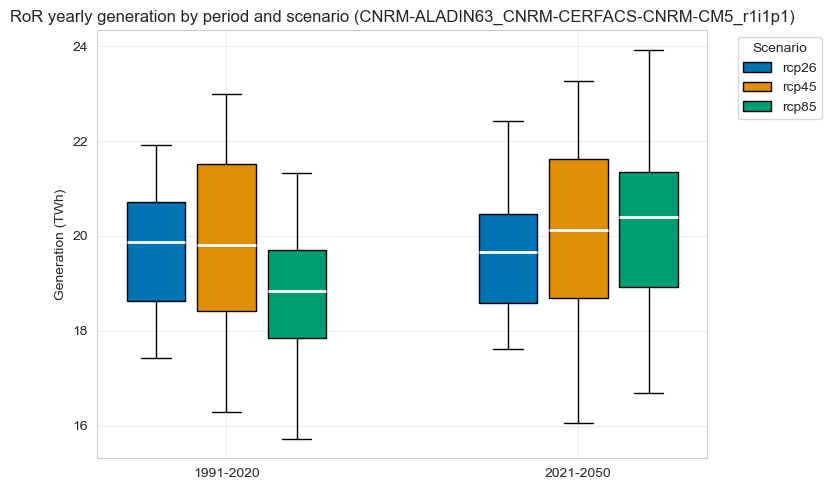

In [21]:
import numpy as np
from matplotlib.patches import Patch

# prepare data per period and scenario
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df = {"rcp26": df26, "rcp45": df45, "rcp85": df85}
scenario_colors = {"rcp26": "C0", "rcp45": "C1", "rcp85": "C2"}

group_bases = np.array([0.0, 3.0])  # center positions for the two periods
offsets = np.array([-0.6, 0.0, 0.6])  # offsets for the three scenarios within a group
positions = []
data_list = []
period_labels = []

for i, (pname, (y0, y1)) in enumerate(periods.items()):
    base = group_bases[i]
    for off, scen in zip(offsets, scenario_order):
        pos = base + off
        positions.append(pos)
        df = scenario_to_df[scen]
        vals = df[(df.year >= y0) & (df.year <= y1)]["gen_yearly"].to_numpy()
        data_list.append(vals)
    period_labels.append(pname)

# plotting
fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data_list, positions=positions, widths=0.5, patch_artist=True, showfliers=False
)

# color boxes by scenario
for i, patch in enumerate(box["boxes"]):
    scen = scenario_order[i % 3]
    color = scenario_colors[scen]
    patch.set_facecolor(color)
    patch.set_edgecolor("k")
    # whiskers/caps/medians
    box["whiskers"][2 * i].set_color("k")
    box["whiskers"][2 * i + 1].set_color("k")
    box["caps"][2 * i].set_color("k")
    box["caps"][2 * i + 1].set_color("k")
    box["medians"][i].set_color("white")
    box["medians"][i].set_linewidth(2)

# xticks centered per group
group_centers = [np.mean(positions[i * 3 : i * 3 + 3]) for i in range(len(group_bases))]
ax.set_xticks(group_centers)
ax.set_xticklabels(period_labels)
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"RoR yearly generation by period and scenario ({climate_model_chain})")

# legend
legend_handles = [
    Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in scenario_order
]
ax.legend(
    handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(1.2, 1)
)

plt.tight_layout()
plt.show()

In [22]:
ds_trends_rcp26 = compute_theilsen_trends(df_combined, "gen_yearly_rcp26")
ds_trends_rcp45 = compute_theilsen_trends(df_combined, "gen_yearly_rcp45")
ds_trends_rcp85 = compute_theilsen_trends(df_combined, "gen_yearly_rcp85")

# keep per-scenario results and a combined lookup
ds_trends = (
    pd.concat(
        [
            ds_trends_rcp26.assign(scenario="rcp26"),
            ds_trends_rcp45.assign(scenario="rcp45"),
            ds_trends_rcp85.assign(scenario="rcp85"),
        ]
    )
    .reset_index()
    .set_index(["scenario", "period"])
)

display(ds_trends)

n_years  slope_TWh_per_year  slope_TWh_per_decade  \
scenario period                                                         
rcp26    1991-2020       30           -0.031323             -0.313226   
         2021-2050       30           -0.029396             -0.293960   
rcp45    1991-2020       30            0.003441              0.034408   
         2021-2050       30           -0.043696             -0.436961   
rcp85    1991-2020       30           -0.040766             -0.407657   
         2021-2050       30            0.101430              1.014301   

                    slope_CI_lower  slope_CI_upper   mean_TWh  \
scenario period                                                 
rcp26    1991-2020       -0.088276        0.038398  19.772241   
         2021-2050       -0.085737        0.020723  19.688822   
rcp45    1991-2020       -0.087131        0.102809  19.802602   
         2021-2050       -0.120550        0.042277  20.209797   
rcp85    1991-2020       -0.096916        0.027323  18.847630   
         2021-2050        0.031271        0.160778  20.134164   

                    rel_change_pct_per_decade                      method  
scenario period                                                            
rcp26    1991-2020                  -1.584171  scipy.theilslopes (95% CI)  
         2021-2050                  -1.493029  scipy.theilslopes (95% CI)  
rcp45    1991-2020                   0.173757  scipy.theilslopes (95% CI)  
         2021-2050                  -2.162125  scipy.theilslopes (95% CI)  
rcp85    1991-2020                  -2.162910  scipy.theilslopes (95% CI)  
         2021-2050                   5.037711  scipy.theilslopes (95% CI)

## Post-bias correction comparison

### Get bias correction factors

In [ ]:
# compute using the dataset for the currently selected climate_scenario
for scenario in climate_scenarios:
    print(f"Processing scenario: {scenario}")
    ds_hydropower_generation_per_month = compute_monthly_generation_from_ds(
        ds_gen_dict[scenario], processing.gdf_hydropower_locations, start_year=2000
    )

    df_reported_generation_ror[f"Estimated Generation_{scenario}"] = (
        ds_hydropower_generation_per_month.sel(
            time=slice("2000", str(df_reported_generation_ror["Jahr"].max()))
        ).gen.to_numpy()
    )

Processing scenario: rcp26
Processing scenario: rcp45
Processing scenario: rcp85


In [ ]:
df_monthly_means = df_reported_generation_ror.groupby(
    df_reported_generation_ror["Monat"]
).mean()
for scenario in climate_scenarios:
    df_monthly_means[f"Relative Bias_{scenario}"] = (
        df_monthly_means[f"Estimated Generation_{scenario}"]
        / df_monthly_means["Reported Generation"]
    )
df_monthly_means

,Jahr,Reported Generation,Estimated Generation_rcp26,Estimated Generation_rcp45,Estimated Generation_rcp85,Relative Bias_rcp26,Relative Bias_rcp45,Relative Bias_rcp85
Monat,,,,,,,,
1,2011.0,0.901043,0.863660,0.889548,0.810104,0.958511,0.987242,0.899073
2,2011.0,0.799000,0.793080,0.810691,0.726019,0.992591,1.014633,0.908660
3,2011.0,0.977826,1.053026,1.054297,0.933779,1.076905,1.078205,0.954954
4,2011.0,1.246826,1.491810,1.500013,1.333192,1.196486,1.203065,1.069268
5,2011.0,1.871870,2.079310,2.070373,2.025756,1.110820,1.106046,1.082210
6,2011.0,2.143652,2.304693,2.343769,2.207330,1.075125,1.093353,1.029706
7,2011.0,2.150348,2.249128,2.244795,2.131842,1.045937,1.043922,0.991394
8,2011.0,1.943522,1.955482,1.992646,1.910107,1.006154,1.025276,0.982807
9,2011.0,1.458000,1.726471,1.763771,1.602548,1.184137,1.209720,1.099141


In [ ]:
bias_correction_factors = {}
for scenario in climate_scenarios:
    monthly_values = (1 / df_monthly_means[f"Relative Bias_{scenario}"]).to_numpy()
    indices_months = ds_gen_dict[scenario].groupby("time.month").groups
    monthly_bias_correction_factors = np.empty(len(ds_gen_dict[scenario].time))
    for i, month in enumerate(indices_months):
        monthly_bias_correction_factors[indices_months[month]] = monthly_values[i]

    bias_correction_factors[scenario] = xr.DataArray(
        monthly_bias_correction_factors,
        dims=["time"],
        coords={"time": (["time"], ds_gen_dict[scenario].time.values)},
        name="bias_correction_factor",
    )

In [ ]:
df_reported_generation_ror_corrected = df_reported_generation_ror.copy()
for scenario in climate_scenarios:
    df_reported_generation_ror_corrected[f"Estimated Generation_{scenario}"] = (
        df_reported_generation_ror_corrected.apply(
            lambda r: r[f"Estimated Generation_{scenario}"]
            * (1 / df_monthly_means[f"Relative Bias_{scenario}"])
            .loc[r["Monat"]]
            .item(),
            axis=1,
        )
    )

<Axes: title={'center': 'Corrected RoR generation'}>

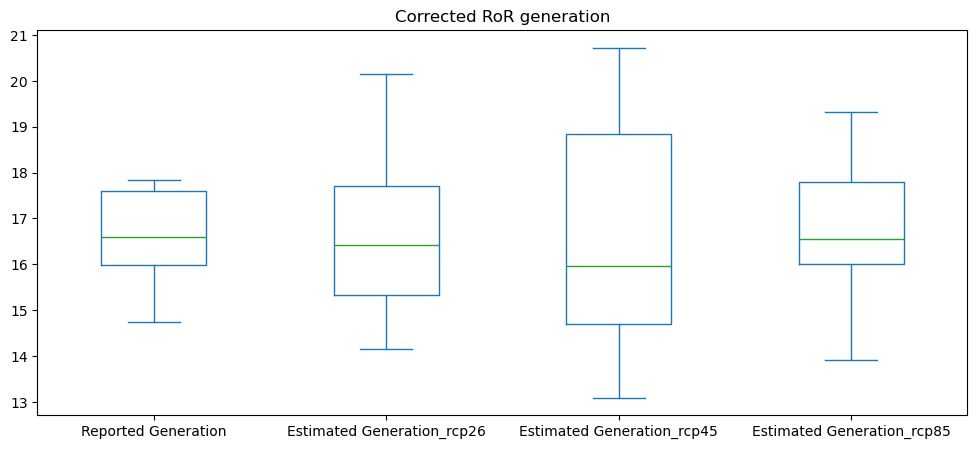

In [ ]:
df_reported_generation_ror_corrected.groupby("Jahr").sum()[
    [
        "Reported Generation",
        "Estimated Generation_rcp26",
        "Estimated Generation_rcp45",
        "Estimated Generation_rcp85",
    ]
].plot(kind="box", title="Corrected RoR generation", figsize=(12, 5))

### Yearly comparison

In [23]:
(
    yearly_da_rcp26_corrected,
    df26_corrected,
) = compute_yearly_sum_from_dataset(
    ds_gen_rcp26 * bias_correction_factors["rcp26"]["bias_correction_factor"], "gen_yearly"
)
(
    yearly_da_rcp45_corrected,
    df45_corrected,
) = compute_yearly_sum_from_dataset(
    ds_gen_rcp45 * bias_correction_factors["rcp45"]["bias_correction_factor"], "gen_yearly"
)
(
    yearly_da_rcp85_corrected,
    df85_corrected,
) = compute_yearly_sum_from_dataset(
    ds_gen_rcp85 * bias_correction_factors["rcp85"]["bias_correction_factor"], "gen_yearly"
)
(
    yearly_da_obs_corrected,
    df_obs_corrected,
) = compute_yearly_sum_from_dataset(
    ds_gen_obs * bias_correction_factors["obs"]["bias_correction_factor"], "gen_yearly"
)


# combine into one dataframe (aligned by year)
df_combined_corrected = pd.merge(
    df26_corrected[["year", "gen_yearly"]],
    df45_corrected[["year", "gen_yearly"]],
    on="year",
    suffixes=("_rcp26", "_rcp45"),
)
df_combined_corrected = pd.merge(
    df_combined_corrected,
    df85_corrected[["year", "gen_yearly"]].rename(
        {"gen_yearly": "gen_yearly_rcp85"}, axis=1
    ),
    on="year",
)
df_combined_corrected = pd.merge(
    df_combined_corrected,
    df_obs_corrected[["year", "gen_yearly"]].rename(
        {"gen_yearly": "gen_yearly_obs"}, axis=1
    ),
    on="year",
    how="left"
)

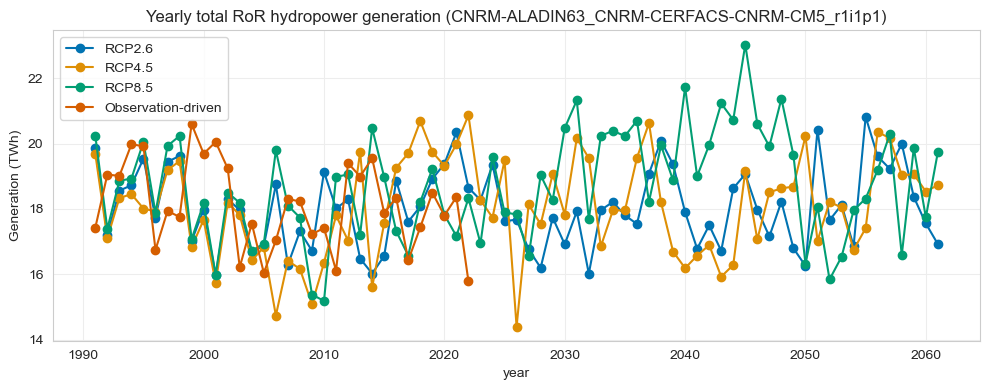

In [24]:
# plot both series
ax = df_combined_corrected.set_index("year").plot(
    figsize=(10, 4), marker="o", linestyle="-"
)
ax.set_title(f"Yearly total RoR hydropower generation ({climate_model_chain})")
ax.set_ylabel("Generation (TWh)")
ax.legend(["RCP2.6", "RCP4.5", "RCP8.5", "Observation-driven"])
plt.tight_layout()

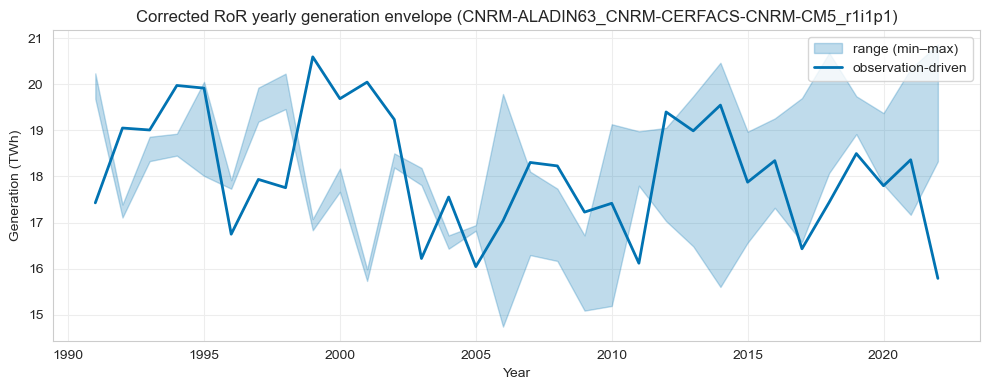

In [25]:
# plot envelope (min/max across corrected scenarios) with median line
cols = [c for c in df_combined_corrected.columns if c.startswith("gen_yearly_rcp")]
df_plot = df_combined_corrected.dropna().sort_values("year")
years = df_plot["year"].to_numpy()
vals = df_plot[cols]

ymin = vals.min(axis=1).to_numpy()
ymax = vals.max(axis=1).to_numpy()
yobs = df_plot["gen_yearly_obs"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(years, ymin, ymax, color="C0", alpha=0.25, label="range (min–max)")
ax.plot(years, yobs, color="C0", lw=2, label="observation-driven")
ax.set_xlabel("Year")
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"Corrected RoR yearly generation envelope ({climate_model_chain})")
ax.legend()
plt.tight_layout()
plt.show()

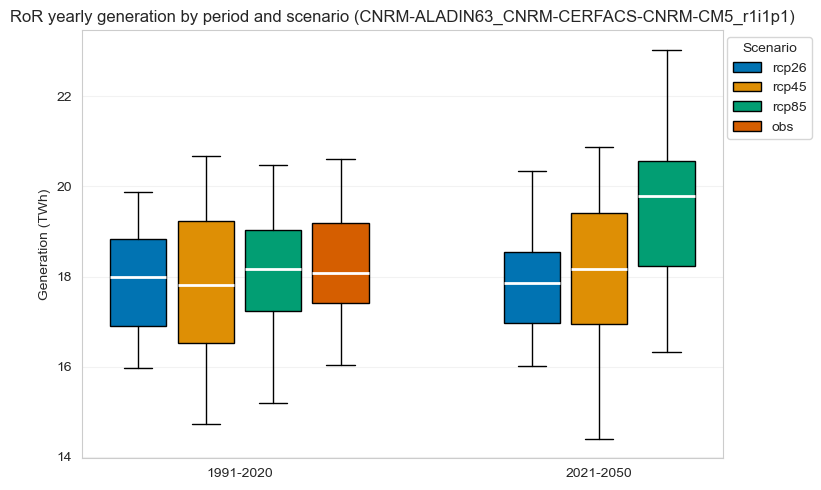

In [26]:
pal = sns.color_palette("colorblind", 4)

# prepare data per period and scenario
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df = {
    "rcp26": df26_corrected,
    "rcp45": df45_corrected,
    "rcp85": df85_corrected,
}
# include obs color as well
scenario_colors = dict(zip(scenario_order + ["obs"], pal))

group_bases = np.array([0.0, 3.5])  # center positions for the two periods
offsets_base = np.array([-0.9, -0.3, 0.3, 0.9])  # offsets for up to 4 items within a group
positions = []
data_list = []
data_scenarios = []
period_labels = []

first_period_name = list(periods.keys())[0]

for i, (pname, (y0, y1)) in enumerate(periods.items()):
    base = group_bases[i]
    # include obs only for the first period
    scenarios = scenario_order + (["obs"] if pname == first_period_name else [])
    for off, scen in zip(offsets_base[: len(scenarios)], scenarios):
        pos = base + off
        positions.append(pos)
        if scen == "obs":
            df = df_obs_corrected
        else:
            df = scenario_to_df[scen]
        vals = df[(df.year >= y0) & (df.year <= y1)]["gen_yearly"].to_numpy()
        data_list.append(vals)
        data_scenarios.append(scen)
    period_labels.append(pname)

# plotting
fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data_list,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# color boxes by the actual scenario order used
for i, patch in enumerate(box["boxes"]):
    scen = data_scenarios[i]
    color = scenario_colors[scen]
    patch.set_facecolor(color)
    patch.set_edgecolor("k")
    # whiskers/caps/medians
    box["whiskers"][2 * i].set_color("k")
    box["whiskers"][2 * i + 1].set_color("k")
    box["caps"][2 * i].set_color("k")
    box["caps"][2 * i + 1].set_color("k")
    box["medians"][i].set_color("white")
    box["medians"][i].set_linewidth(2)

# xticks centered per group
group_centers = [np.mean(positions[i * (len(scenario_order) + 1) : i * (len(scenario_order) + 1) + (len(scenario_order) + 1)]) for i in range(len(group_bases))]
ax.set_xticks(group_centers)
ax.set_xticklabels(period_labels)
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"RoR yearly generation by period and scenario ({climate_model_chain})")

# grid: only horizontal lines (no vertical grid lines)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", color="gray", alpha=0.1)
ax.xaxis.grid(False)

# legend using seaborn palette colors (include obs)
legend_order = scenario_order + ["obs"]
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in legend_order]
ax.legend(handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

### Monthly comparison

In [27]:
(
    monthly_da_rcp26_corrected,
    df26_corrected_monthly,
) = compute_monthly_sum_from_dataset(
    ds_gen_rcp26 * bias_correction_factors["rcp26"]["bias_correction_factor"], "gen_monthly"
)
(
    monthly_da_rcp45_corrected,
    df45_corrected_monthly,
) = compute_monthly_sum_from_dataset(
    ds_gen_rcp45 * bias_correction_factors["rcp45"]["bias_correction_factor"], "gen_monthly"
)
(
    monthly_da_rcp85_corrected,
    df85_corrected_monthly,
) = compute_monthly_sum_from_dataset(
    ds_gen_rcp85 * bias_correction_factors["rcp85"]["bias_correction_factor"], "gen_monthly"
)

(
    monthly_da_obs_corrected,
    df_obs_corrected_monthly,
) = compute_monthly_sum_from_dataset(
    ds_gen_obs * bias_correction_factors["obs"]["bias_correction_factor"], "gen_monthly"
)

In [28]:
# combine into one dataframe (aligned by year)
df_combined_corrected_monthly = pd.merge(
    df26_corrected_monthly,
    df45_corrected_monthly,
    on=["time", "year", "month"],
    suffixes=("_rcp26", "_rcp45"),
)
df_combined_corrected_monthly = pd.merge(
    df_combined_corrected_monthly,
    df85_corrected_monthly.rename(
        {"gen_monthly": "gen_monthly_rcp85"}, axis=1
    ),
    on=["time", "year", "month"],
)
df_combined_corrected_monthly = pd.merge(
    df_combined_corrected_monthly,
    df_obs_corrected_monthly.rename(
        {"gen_monthly": "gen_monthly_obs"}, axis=1
    ),
    on=["time", "year", "month"],
    how="left"
)

# put time, year and month at the beginning
cols = ["time", "year", "month"] + [c for c in df_combined_corrected_monthly.columns if c not in ("time", "year", "month")]
df_combined_corrected_monthly = df_combined_corrected_monthly[cols]
df_combined_corrected_monthly

,time,year,month,gen_monthly_rcp26,gen_monthly_rcp45,gen_monthly_rcp85,gen_monthly_obs
0,1991-01-31,1991,1,1.548995,1.536186,1.552036,1.070917
1,1991-02-28,1991,2,0.995731,0.986870,1.033643,0.588293
2,1991-03-31,1991,3,0.914666,0.912125,0.966522,1.505808
3,1991-04-30,1991,4,1.205784,1.199272,1.286380,1.090683
4,1991-05-31,1991,5,1.960559,1.969827,1.921353,1.404490
...,...,...,...,...,...,...,...
847,2061-08-31,2061,8,1.539042,2.171069,2.078987,NaN
848,2061-09-30,2061,9,1.172421,1.561648,2.195672,NaN
849,2061-10-31,2061,10,1.146939,1.118509,1.486471,NaN
850,2061-11-30,2061,11,0.921433,0.986991,1.427125,NaN


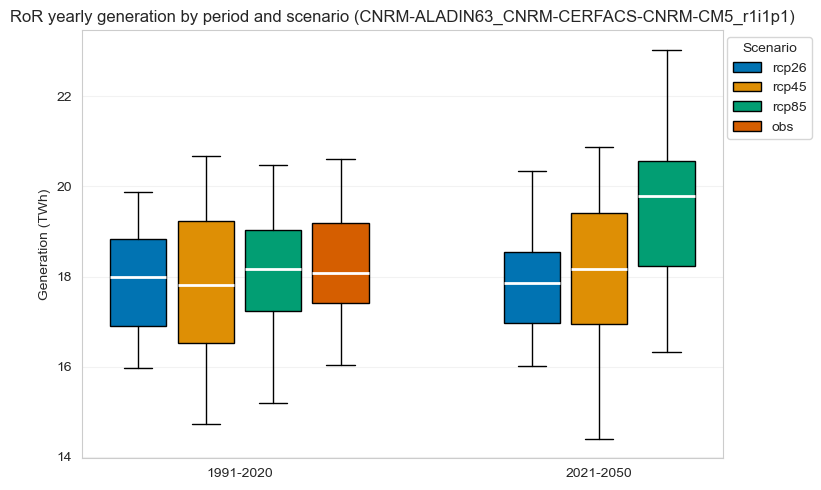

In [29]:
pal = sns.color_palette("colorblind", 4)

# prepare data per period and scenario
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df = {
    "rcp26": df26_corrected,
    "rcp45": df45_corrected,
    "rcp85": df85_corrected,
}
# include obs color as well
scenario_colors = dict(zip(scenario_order + ["obs"], pal))

group_bases = np.array([0.0, 3.5])  # center positions for the two periods
offsets_base = np.array([-0.9, -0.3, 0.3, 0.9])  # offsets for up to 4 items within a group
positions = []
data_list = []
data_scenarios = []
period_labels = []

first_period_name = list(periods.keys())[0]

for i, (pname, (y0, y1)) in enumerate(periods.items()):
    base = group_bases[i]
    # include obs only for the first period
    scenarios = scenario_order + (["obs"] if pname == first_period_name else [])
    for off, scen in zip(offsets_base[: len(scenarios)], scenarios):
        pos = base + off
        positions.append(pos)
        if scen == "obs":
            df = df_obs_corrected
        else:
            df = scenario_to_df[scen]
        vals = df[(df.year >= y0) & (df.year <= y1)]["gen_yearly"].to_numpy()
        data_list.append(vals)
        data_scenarios.append(scen)
    period_labels.append(pname)

# plotting
fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data_list,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# color boxes by the actual scenario order used
for i, patch in enumerate(box["boxes"]):
    scen = data_scenarios[i]
    color = scenario_colors[scen]
    patch.set_facecolor(color)
    patch.set_edgecolor("k")
    # whiskers/caps/medians
    box["whiskers"][2 * i].set_color("k")
    box["whiskers"][2 * i + 1].set_color("k")
    box["caps"][2 * i].set_color("k")
    box["caps"][2 * i + 1].set_color("k")
    box["medians"][i].set_color("white")
    box["medians"][i].set_linewidth(2)

# xticks centered per group
group_centers = [np.mean(positions[i * (len(scenario_order) + 1) : i * (len(scenario_order) + 1) + (len(scenario_order) + 1)]) for i in range(len(group_bases))]
ax.set_xticks(group_centers)
ax.set_xticklabels(period_labels)
ax.set_ylabel("Generation (TWh)")
ax.set_title(f"RoR yearly generation by period and scenario ({climate_model_chain})")

# grid: only horizontal lines (no vertical grid lines)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", color="gray", alpha=0.1)
ax.xaxis.grid(False)

# legend using seaborn palette colors (include obs)
legend_order = scenario_order + ["obs"]
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in legend_order]
ax.legend(handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

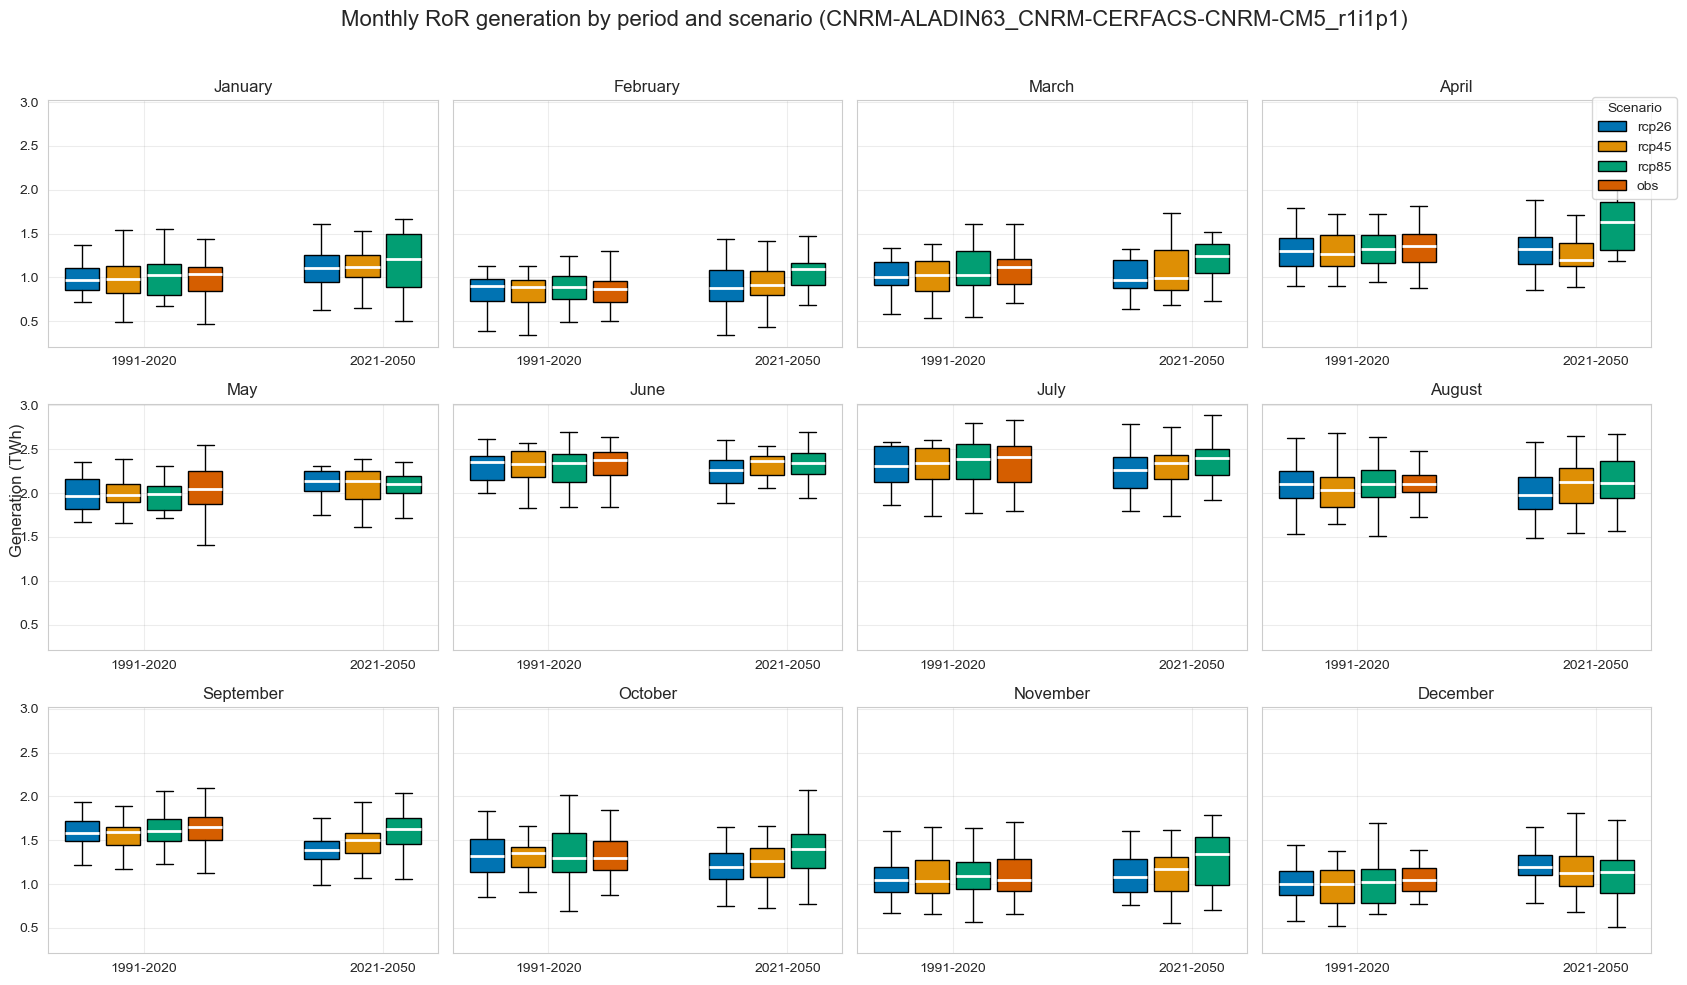

In [30]:
import calendar
pal = sns.color_palette("colorblind", 4)

# prepare data per period and scenario (monthly dataframes from previous cell)
scenario_order = ["rcp26", "rcp45", "rcp85"]
scenario_to_df_monthly = {
    "rcp26": df26_corrected_monthly,
    "rcp45": df45_corrected_monthly,
    "rcp85": df85_corrected_monthly,
}
# include obs color as well
scenario_colors = dict(zip(scenario_order + ["obs"], pal))

# plotting layout: one subplot per month (3 rows x 4 cols)
ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

# group layout parameters (same grouping approach as yearly plot)
group_bases = np.array([0.0, 3.5])  # center positions for the two periods
offsets_base = np.array([-0.9, -0.3, 0.3, 0.9])  # offsets for up to 4 items within a group
first_period_name = list(periods.keys())[0]


for month in range(1, 13):
    ax = axes[month - 1]
    positions = []
    data_list = []
    data_scenarios = []

    # build data list: for each period, for each scenario (obs only in first period), collect monthly values
    for i, (pname, (y0, y1)) in enumerate(periods.items()):
        base = group_bases[i]
        scenarios = scenario_order + (["obs"] if pname == first_period_name else [])
        for off, scen in zip(offsets_base[: len(scenarios)], scenarios):
            pos = base + off
            positions.append(pos)
            if scen == "obs":
                df = df_obs_corrected_monthly
            else:
                df = scenario_to_df_monthly[scen]
            # select the month and the years in the period
            vals = df[(df["month"] == month) & (df["year"] >= y0) & (df["year"] <= y1)]["gen_monthly"].to_numpy()
            data_list.append(vals)
            data_scenarios.append(scen)

    # draw boxplot for this month
    if len(data_list) == 0:
        continue
    box = ax.boxplot(
        data_list,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
    )

    # color boxes by scenario
    for i, patch in enumerate(box["boxes"]):
        scen = data_scenarios[i]
        color = scenario_colors.get(scen, "C3")
        patch.set_facecolor(color)
        patch.set_edgecolor("k")
        # whiskers/caps/medians
        box["whiskers"][2 * i].set_color("k")
        box["whiskers"][2 * i + 1].set_color("k")
        box["caps"][2 * i].set_color("k")
        box["caps"][2 * i + 1].set_color("k")
        box["medians"][i].set_color("white")
        box["medians"][i].set_linewidth(2)

    # xticks centered per group (periods)
    # compute approximate centers using group_bases
    ax.set_xticks(group_bases)
    ax.set_xticklabels(list(periods.keys()))
    ax.set_title(calendar.month_name[month])
    ax.grid(axis="y", linestyle="-", color="gray", alpha=0.15)

# common y label and overall title
fig.supylabel("Generation (TWh)")
fig.suptitle(f"Monthly RoR generation by period and scenario ({climate_model_chain})", fontsize=16)

# legend (scenarios + obs)
legend_order = scenario_order + ["obs"]
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in legend_order]
fig.legend(handles=legend_handles, title="Scenario", loc="upper right", bbox_to_anchor=(0.95, 0.9))

plt.tight_layout(rect=[0, 0, 0.94, 0.96])
plt.show()


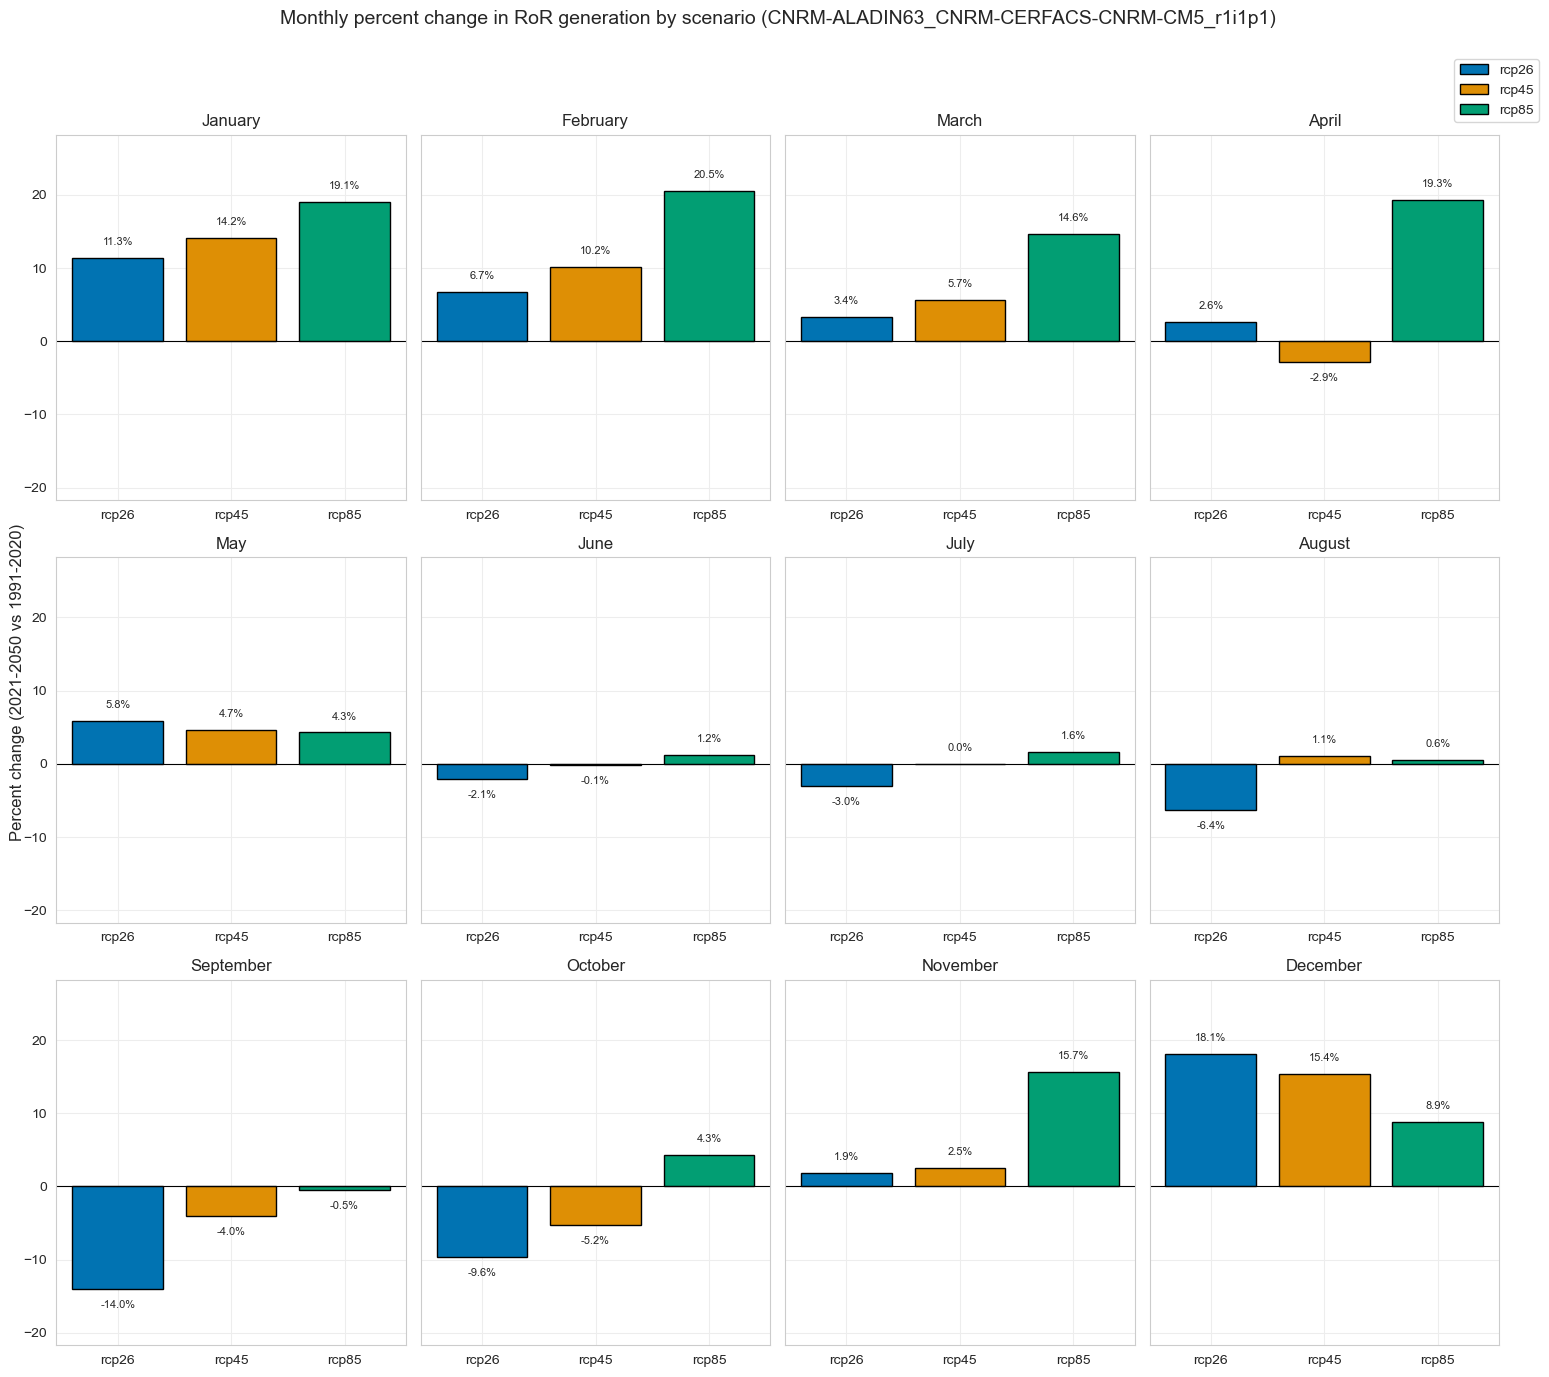

In [31]:
scenarios_plot = scenario_order
# mapping to monthly dataframes
mapping_monthly = {
    "rcp26": df26_corrected_monthly,
    "rcp45": df45_corrected_monthly,
    "rcp85": df85_corrected_monthly,
}

# compute percent change (period2 vs period1) per month and scenario
p0, p1 = list(periods.values())
pct_change = pd.DataFrame(index=range(1, 13), columns=scenarios_plot, dtype=float)

for m in range(1, 13):
    for scen in scenarios_plot:
        dfm = mapping_monthly.get(scen)
        if dfm is None:
            pct_change.at[m, scen] = np.nan
            continue
        mean1 = dfm[(dfm["month"] == m) & (dfm["year"] >= p0[0]) & (dfm["year"] <= p0[1])]["gen_monthly"].mean()
        mean2 = dfm[(dfm["month"] == m) & (dfm["year"] >= p1[0]) & (dfm["year"] <= p1[1])]["gen_monthly"].mean()
        if pd.isna(mean1) or mean1 == 0:
            pct_change.at[m, scen] = np.nan
        else:
            pct_change.at[m, scen] = 100.0 * (mean2 - mean1) / mean1

# plotting: one subplot per month (3x4)
ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 14), sharey=True)
axes = axes.flatten()

for month in range(1, 13):
    ax = axes[month - 1]
    vals = pct_change.loc[month, scenarios_plot].to_numpy(dtype=float)
    colors = [scenario_colors.get(s, "gray") for s in scenarios_plot]
    x = np.arange(len(scenarios_plot))
    bars = ax.bar(x, vals, color=colors, edgecolor="k")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios_plot, rotation=0)
    ax.set_title(calendar.month_name[month])
    # annotate bars
    for rect, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(rect.get_x() + rect.get_width() / 2, v + (1.5 if v >= 0 else -1.5), f"{v:.1f}%", ha="center", va=("bottom" if v >= 0 else "top"), fontsize=8)
# global y label and title
fig.supylabel("Percent change (2021-2050 vs 1991-2020)")
fig.suptitle(f"Monthly percent change in RoR generation by scenario ({climate_model_chain})", fontsize=14)

# legend (scenarios)
legend_handles = [Patch(facecolor=scenario_colors[s], edgecolor="k", label=s) for s in scenarios_plot]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.95))
# increase upper ylim by 10% (fallback absolute padding if range is zero)
for ax in axes.flatten():
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - 0.5, ymax + 0.5)

plt.tight_layout(rect=[0, 0, 0.96, 0.94])
plt.show()

# SPEED2ZERO outputs

In [ ]:
output_dir = Path("/net/exo/landclim_nobackup/FTP/yhaddad/")
for scen in ds_gen_dict.keys():
    print(f"Saving corrected dataset for scenario: {scen}")
    output_path = (
        output_dir
        / "hydropower_ch"
        / f"ds_hydropower_ror_{processing.climate_model_chain}_{scen}.nc"
    )
    if not output_path.exists():
        with ProgressBar(dt=1):
            (ds_gen_dict[scen] * bias_correction_factors[scen]).sel(
                time=slice("2018", "2052")
            ).to_netcdf(output_path, mode="w")

[########################################] | 100% Completed | 290.50 s
[########################################] | 100% Completed | 283.45 s
[########################################] | 100% Completed | 187.73 s


In [33]:
# Produce percent-change CSVs per scenario using centered 10-year windows [center-4, center+5]
# Baseline: for each scenario, use that scenario's 1991-2020 mean (obs not used)

# centers and window definition
centers = [2030, 2040, 2050]
window_half_before = 9
window_half_after = 10

base_out = Path("../../data")
base_out.mkdir(parents=True, exist_ok=True)

scenarios = ['rcp26', 'rcp45', 'rcp85']
mapping_yearly = {
    'rcp26': df26_corrected,
    'rcp45': df45_corrected,
    'rcp85': df85_corrected,
}
mapping_monthly = {
    'rcp26': df26_corrected_monthly,
    'rcp45': df45_corrected_monthly,
    'rcp85': df85_corrected_monthly,
}

for scen in scenarios:
    dfy = mapping_yearly.get(scen)
    dfm = mapping_monthly.get(scen)
    if dfy is None or dfm is None:
        print(f"Skipping scenario {scen}: missing dataframes")
        continue

    # baseline computed from the scenario itself over 1991-2020
    baseline_yearly = dfy[(dfy['year'] >= 1991) & (dfy['year'] <= 2020)]['gen_yearly']
    baseline_yearly_mean = baseline_yearly.mean()

    baseline_monthly_df = dfm[(dfm['year'] >= 1991) & (dfm['year'] <= 2020)]
    baseline_monthly_mean = baseline_monthly_df.groupby('month')['gen_monthly'].mean()

    out_dir = base_out / scen
    out_dir.mkdir(parents=True, exist_ok=True)

    rows_yearly = []
    rows_monthly = []

    for center in centers:
        start = center - window_half_before
        end = center + window_half_after

        # yearly: mean across the window
        dec_mean = dfy[(dfy['year'] >= start) & (dfy['year'] <= end)]['gen_yearly'].mean()
        if pd.isna(baseline_yearly_mean) or baseline_yearly_mean == 0:
            pct = np.nan
        else:
            pct = round(100.0 * (dec_mean - baseline_yearly_mean) / baseline_yearly_mean, 2)
        # time: use end-of-center-year timestamp (YYYY-12-31T23:00)
        ts_year = pd.Timestamp(year=center, month=12, day=31, hour=23)
        rows_yearly.append({'time': ts_year.strftime('%Y-%m-%dT%H:%M'), 'area': 'switzerland', 'ror': pct, 'unit': '%'})

        # monthly: for each calendar month compute mean over the window and compare to baseline monthly mean
        for m in range(1, 13):
            dec_mean_m = dfm[(dfm['year'] >= start) & (dfm['year'] <= end) & (dfm['month'] == m)]['gen_monthly'].mean()
            base_m = baseline_monthly_mean.get(m, np.nan)
            if pd.isna(base_m) or base_m == 0:
                pct_m = np.nan
            else:
                pct_m = round(100.0 * (dec_mean_m - base_m) / base_m, 2)
            # time: last day of month in the center year at 23:00
            last_day = calendar.monthrange(center, m)[1]
            ts_m = pd.Timestamp(year=center, month=m, day=last_day, hour=23)
            rows_monthly.append({'time': ts_m.strftime('%Y-%m-%dT%H:%M'), 'area': 'switzerland', 'ror': pct_m, 'unit': '%'})

    # build dataframes and save CSVs
    df_yearly_export = pd.DataFrame(rows_yearly)[['time', 'area', 'ror', 'unit']]
    df_monthly_export = pd.DataFrame(rows_monthly)[['time', 'area', 'ror', 'unit']]

    # sort and write
    df_yearly_export = df_yearly_export.sort_values('time').reset_index(drop=True)
    df_monthly_export = df_monthly_export.sort_values('time').reset_index(drop=True)

    out_yearly = out_dir / 'switzerland_ror_percent_change_yearly.csv'
    out_monthly = out_dir / 'switzerland_ror_percent_change_monthly.csv'

    df_yearly_export.to_csv(out_yearly, index=False)
    df_monthly_export.to_csv(out_monthly, index=False)

    print(f"Wrote {scen}: {out_yearly} ({len(df_yearly_export)} rows), {out_monthly} ({len(df_monthly_export)} rows)")

# done
print('All scenario CSVs written under:', base_out)


Wrote rcp26: ../../data/rcp26/switzerland_ror_percent_change_yearly.csv (3 rows), ../../data/rcp26/switzerland_ror_percent_change_monthly.csv (36 rows)
Wrote rcp45: ../../data/rcp45/switzerland_ror_percent_change_yearly.csv (3 rows), ../../data/rcp45/switzerland_ror_percent_change_monthly.csv (36 rows)
Wrote rcp85: ../../data/rcp85/switzerland_ror_percent_change_yearly.csv (3 rows), ../../data/rcp85/switzerland_ror_percent_change_monthly.csv (36 rows)
All scenario CSVs written under: ../../data
